In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import csv

def normal_distribution(seed=42, X_min=0.0, X_max=1.0, n_points=50, 
                             std_low=0.01, std_high=0.3, 
                             dist_min=0.0, dist_max=1.0,
                             csv_filename="normal_distribution.csv"):
    """
    Plots a normal distribution whose parameters are determined from [dist_min, dist_max] 
    (mean is set to the midpoint of that range and a random std is chosen) while discretizing
    and plotting over [X_min, X_max]. The probability for each bin is computed (density * bin width)
    so that the y-axis represents probability. The data is written to a CSV file with three rows:
      - Row 1: indices (starting at 1)
      - Row 2: x-axis values (the discretization values)
      - Row 3: probabilities for each bin.
    
    Parameters:
      seed (int): Seed for reproducibility.
      X_min (float): Minimum x-value for discretization.
      X_max (float): Maximum x-value for discretization.
      n_points (int): Number of discrete points (bins).
      std_low (float): Lower bound for random standard deviation.
      std_high (float): Upper bound for random standard deviation.
      dist_min (float): Minimum x-value for the distribution parameters.
      dist_max (float): Maximum x-value for the distribution parameters.
      csv_filename (str): Name of the CSV file to save the data.
    """
    np.random.seed(seed)
    
    # Distribution parameters from the separate distribution range
    mean = (dist_min + dist_max) / 2.0
    std = np.random.uniform(std_low, std_high)
    
    # Discretize the plotting domain [X_min, X_max]
    x_values = np.linspace(X_min, X_max, n_points)
    bin_width = (X_max - X_min) / n_points
    
    # Compute PDF (using distribution parameters) and convert to probability per bin
    pdf_values = norm.pdf(x_values, loc=mean, scale=std)
    discrete_prob = pdf_values * bin_width
    
    # For a smooth visualization
    x_smooth = np.linspace(X_min, X_max, 500)
    pdf_smooth = norm.pdf(x_smooth, loc=mean, scale=std)
    smooth_prob = pdf_smooth * bin_width
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.bar(x_values, discrete_prob, width=bin_width, edgecolor='black', alpha=0.6, label='Discrete Probability')
    plt.plot(x_smooth, smooth_prob, 'r-', lw=2, label='Smooth Probability')
    plt.xlabel('X')
    plt.ylabel('Probability')
    plt.title(f'Normal Distribution on [{X_min}, {X_max}] with distribution range [{dist_min}, {dist_max}]\n'
              f'(Mean = {mean:.3f}, Std = {std:.3f})')
    plt.legend()
    plt.show()
    
    # Write data to CSV (three rows: indices, x values, and probabilities)
    indices = list(range(1, n_points + 1))
    with open(csv_filename, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(indices)
        writer.writerow(x_values)
        writer.writerow(discrete_prob)
    print(f"Data written to {csv_filename}")

def multimodal_distribution(seed=42, num_peaks=3, X_min=0.0, X_max=1.0, n_points=50, 
                                 std_low=0.02, std_high=0.1,
                                 dist_min=0.0, dist_max=1.0,
                                 csv_filename="multimodal_distribution.csv"):
    """
    Plots a random multimodal distribution as a weighted sum of 'num_peaks' Gaussians.
    Each peak’s parameters (mean and standard deviation) are chosen using the distribution
    range [dist_min, dist_max] while the discretization (and plotting/CSV output) is done 
    over [X_min, X_max]. The discrete probability per bin (normalized and scaled by bin width)
    is computed so that the y-axis represents probability. The data is written to a CSV file 
    with three rows:
      - Row 1: indices (starting at 1)
      - Row 2: x-axis values (the discretization values)
      - Row 3: probabilities for each bin.
    
    Parameters:
      seed (int): Seed for reproducibility.
      num_peaks (int): Number of peaks (modes) in the distribution.
      X_min (float): Minimum x-value for discretization.
      X_max (float): Maximum x-value for discretization.
      n_points (int): Number of discrete points (bins).
      std_low (float): Lower bound for random standard deviations of peaks.
      std_high (float): Upper bound for random standard deviations of peaks.
      dist_min (float): Minimum x-value for the distribution parameters.
      dist_max (float): Maximum x-value for the distribution parameters.
      csv_filename (str): Name of the CSV file to save the data.
    """
    np.random.seed(seed)
    
    x_values = np.linspace(X_min, X_max, n_points)
    bar_width = (X_max - X_min) / n_points
    pdf = np.zeros_like(x_values)
    
    peaks = []
    # Generate peaks using parameters drawn from [dist_min, dist_max]
    for _ in range(num_peaks):
        mean = np.random.uniform(dist_min, dist_max)
        std = np.random.uniform(std_low, std_high)
        weight = np.random.uniform(0.5, 1.5)
        peaks.append((mean, std, weight))
        pdf += weight * norm.pdf(x_values, loc=mean, scale=std)
    
    # Normalize the PDF so its total area equals 1, then scale to probability per bin
    area = np.trapz(pdf, x_values)
    pdf_normalized = pdf / area
    discrete_prob = pdf_normalized * bar_width
    
    x_smooth = np.linspace(X_min, X_max, 500)
    pdf_smooth = np.zeros_like(x_smooth)
    for mean, std, weight in peaks:
        pdf_smooth += weight * norm.pdf(x_smooth, loc=mean, scale=std)
    area_smooth = np.trapz(pdf_smooth, x_smooth)
    pdf_smooth_normalized = pdf_smooth / area_smooth
    smooth_prob = pdf_smooth_normalized * bar_width
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.bar(x_values, discrete_prob, width=bar_width, edgecolor='black', alpha=0.6, label='Discrete Probability')
    plt.plot(x_smooth, smooth_prob, 'r-', lw=2, label='Smooth Probability')
    plt.xlabel('X')
    plt.ylabel('Probability')
    plt.title(f'Multimodal Distribution on [{X_min}, {X_max}] with distribution range [{dist_min}, {dist_max}]\n'
              f'Number of Peaks = {num_peaks}')
    plt.legend()
    plt.show()
    
    # Write data to CSV (three rows: indices, x values, and probabilities)
    indices = list(range(1, n_points + 1))
    with open(csv_filename, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(indices)
        writer.writerow(x_values)
        writer.writerow(discrete_prob)
    print(f"Data written to {csv_filename}")
    
    # Optionally, print the parameters of each peak
    print("Peak parameters (Mean, Std, Weight):")
    for i, (mean, std, weight) in enumerate(peaks):
        print(f" Peak {i+1}: Mean = {mean:.3f}, Std = {std:.3f}, Weight = {weight:.3f}")


In [22]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def plot_result(csv_filename, x_col_index, y_col_index):
    """
    Reads a CSV file and plots the data from two specified columns.
    
    The function:
      - Reads the CSV file assuming the first row contains column headers.
      - Uses the specified column indices (zero-indexed) for x-values and y-values.
      - Plots a bar graph of the raw data with a dynamically computed bar width so that bars do not overlap.
      - Generates a smooth line using cubic interpolation and overlays it on the bar graph.
      - Uses the column names from the header as labels for the x-axis and y-axis.
    
    Parameters:
      csv_filename (str): Path to the CSV file.
      x_col_index (int): Column index for x-values.
      y_col_index (int): Column index for y-values.
    """
    x_values = []
    y_values = []
    
    with open(csv_filename, 'r') as file:
        reader = csv.reader(file)
        # Read the header row and store the column names.
        header = next(reader, None)
        if header is None:
            raise ValueError("CSV file is empty.")
        x_label = header[x_col_index]
        y_label = header[y_col_index]
        
        # Read data rows, converting specified columns to floats.
        for row in reader:
            try:
                x_val = float(row[x_col_index])
                y_val = float(row[y_col_index])
                x_values.append(x_val)
                y_values.append(y_val)
            except ValueError:
                continue  # Skip rows with non-numeric values in these columns.

    # Convert lists to numpy arrays.
    x_values = np.array(x_values)
    y_values = np.array(y_values)
    
    # Sort the data by x-values for a proper smooth curve.
    sorted_indices = np.argsort(x_values)
    x_sorted = x_values[sorted_indices]
    y_sorted = y_values[sorted_indices]
    
    # Dynamically compute bar width:
    # If there is more than one x value, take 80% of the minimum difference.
    if len(x_sorted) > 1:
        differences = np.diff(x_sorted)
        bar_width = 0.8 * np.min(differences)
    else:
        # Default bar width if only one data point.
        bar_width = 1.0

    # Create a cubic interpolation function for a smooth line.
    interp_func = interp1d(x_sorted, y_sorted, kind='cubic', fill_value="extrapolate")
    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 500)
    y_smooth = interp_func(x_smooth)
    
    # Plotting
    plt.figure(figsize=(8, 5))
    # Use align='center' so the bars are centered on the x values.
    plt.bar(x_sorted, y_sorted, width=bar_width, alpha=0.6, label='Data Bars', edgecolor='black', align='center')
    plt.plot(x_smooth, y_smooth, 'r-', lw=2, label='Smooth Line')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f'{x_label} (X) vs {y_label} (Y)')
    plt.legend()
    plt.show()




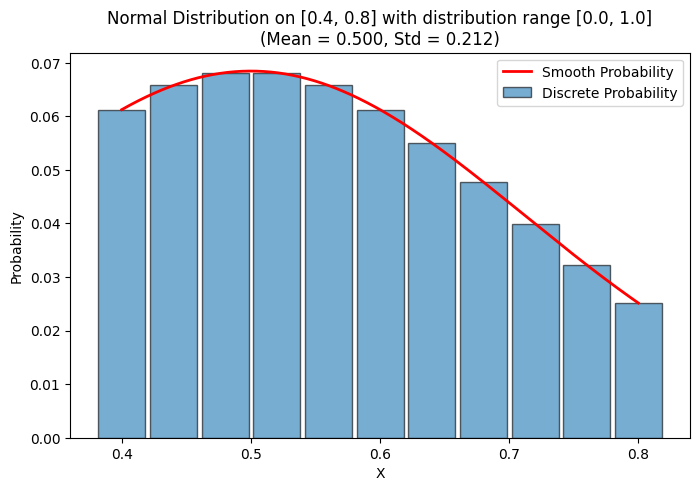

Data written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv


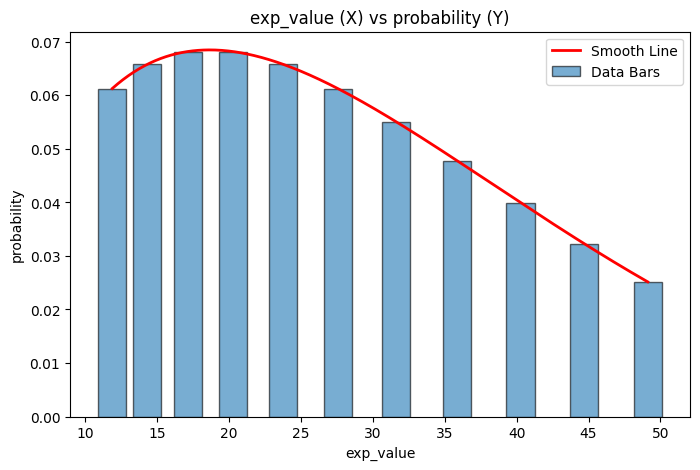

In [23]:
#Gran_low with 11 normal
normal_distribution(seed=123, X_min=0.4, X_max=0.8, n_points=11, std_low=0.01, std_high=0.3, dist_min=0.0, dist_max=1.0, csv_filename="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv")
plot_result("/Users/khangvhuynh/prism-new/prism/tests/result/result.csv", x_col_index=1, y_col_index=2)

/var/folders/bg/_kd1l8gn199c0dxcm5pnsgmc0000gn/T/ipykernel_53636/1413437359.py:112: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, x_values)
/var/folders/bg/_kd1l8gn199c0dxcm5pnsgmc0000gn/T/ipykernel_53636/1413437359.py:120: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_smooth = np.trapz(pdf_smooth, x_smooth)


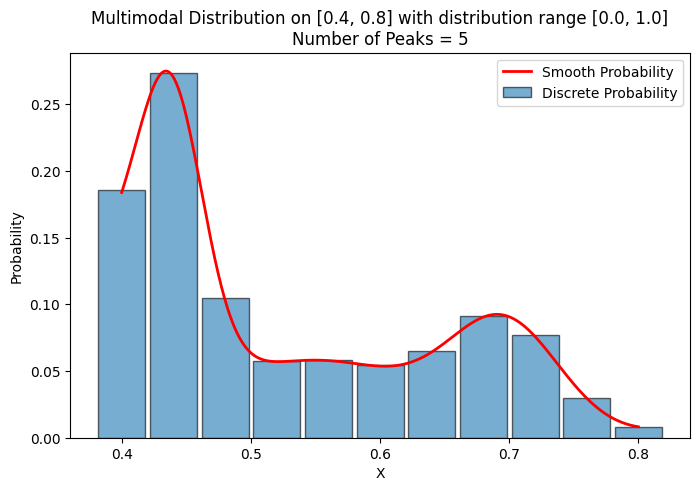

Data written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv
Peak parameters (Mean, Std, Weight):
 Peak 1: Mean = 0.696, Std = 0.043, Weight = 0.727
 Peak 2: Mean = 0.551, Std = 0.078, Weight = 0.923
 Peak 3: Mean = 0.981, Std = 0.075, Weight = 0.981
 Peak 4: Mean = 0.392, Std = 0.047, Weight = 1.229
 Peak 5: Mean = 0.439, Std = 0.025, Weight = 0.898


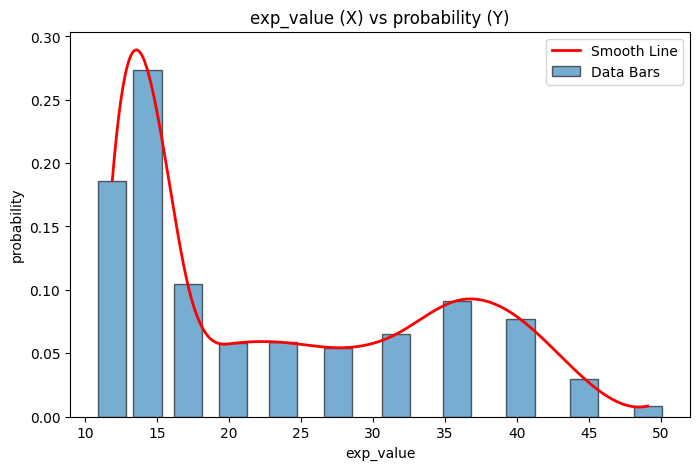

In [24]:
#gran_low with 11 multimodal 5 peaks
multimodal_distribution(seed=123, num_peaks=5, X_min=0.4, X_max=0.8, n_points=11, std_low=0.02, std_high=0.1, dist_min=0.0, dist_max=1.0, csv_filename="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv")
plot_result("/Users/khangvhuynh/prism-new/prism/tests/result/result_2.csv", x_col_index=1, y_col_index=2)

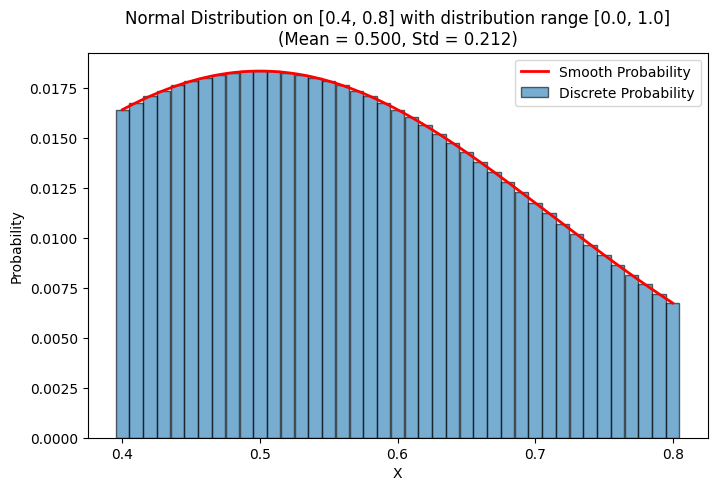

Data written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv


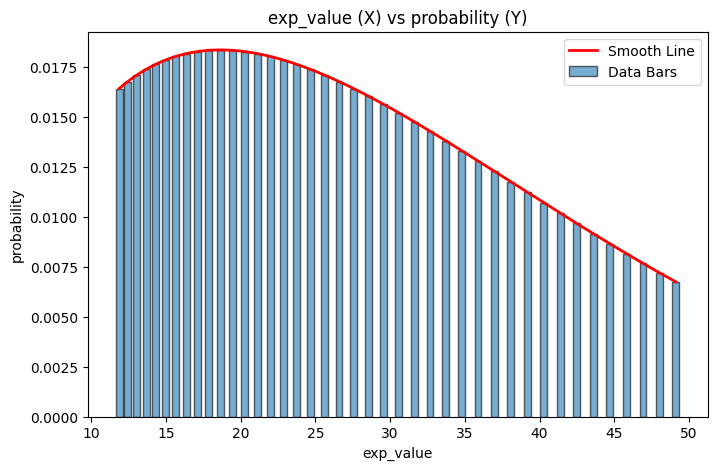

In [25]:
#gran_high with 41 normal
normal_distribution(seed=123, X_min=0.4, X_max=0.8, n_points=41, std_low=0.01, std_high=0.3, dist_min=0.0, dist_max=1.0, csv_filename="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv")
plot_result("/Users/khangvhuynh/prism-new/prism/tests/result/result_1.csv", x_col_index=1, y_col_index=2)

/var/folders/bg/_kd1l8gn199c0dxcm5pnsgmc0000gn/T/ipykernel_53636/1413437359.py:112: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, x_values)
/var/folders/bg/_kd1l8gn199c0dxcm5pnsgmc0000gn/T/ipykernel_53636/1413437359.py:120: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_smooth = np.trapz(pdf_smooth, x_smooth)


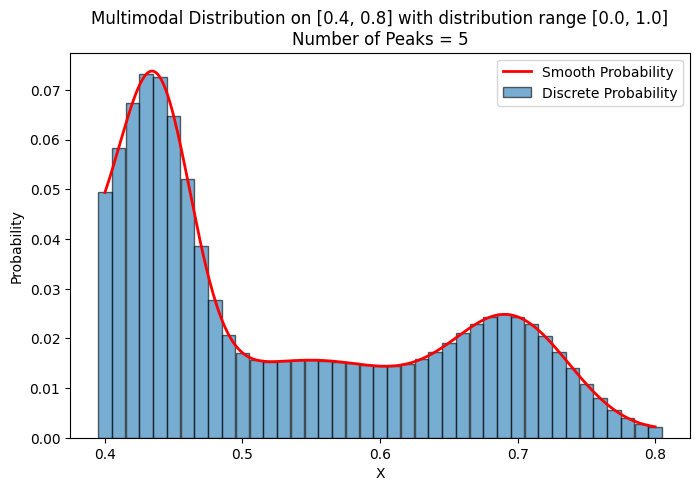

Data written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv
Peak parameters (Mean, Std, Weight):
 Peak 1: Mean = 0.696, Std = 0.043, Weight = 0.727
 Peak 2: Mean = 0.551, Std = 0.078, Weight = 0.923
 Peak 3: Mean = 0.981, Std = 0.075, Weight = 0.981
 Peak 4: Mean = 0.392, Std = 0.047, Weight = 1.229
 Peak 5: Mean = 0.439, Std = 0.025, Weight = 0.898


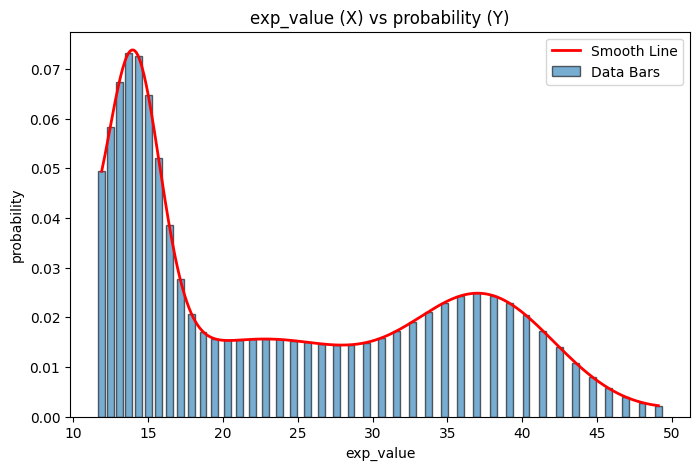

In [26]:
#gran_low with 41 multimodal 5 peaks
multimodal_distribution(seed=123, num_peaks=5, X_min=0.4, X_max=0.8, n_points=41, std_low=0.02, std_high=0.1, dist_min=0.0, dist_max=1.0, csv_filename="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv")
plot_result("/Users/khangvhuynh/prism-new/prism/tests/result/result_3.csv", x_col_index=1, y_col_index=2)

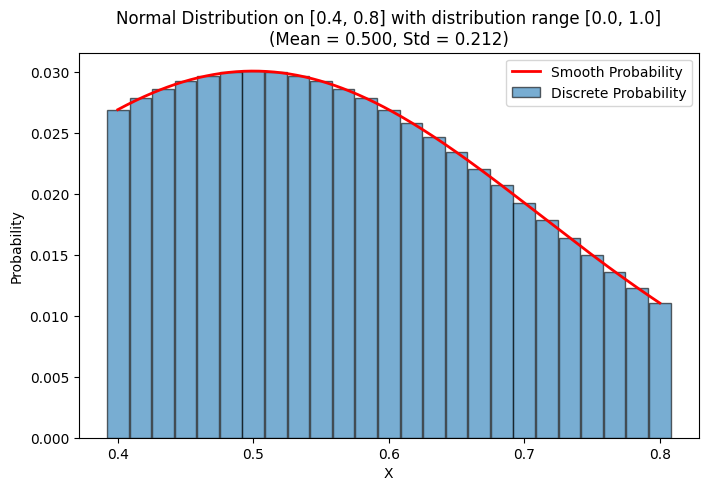

Data written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv


In [39]:
# normal distribution
normal_distribution(seed=123, X_min=0.4, X_max=0.8, n_points=25, std_low=0.01, std_high=0.3, dist_min=0.0, dist_max=1.0, csv_filename="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv")

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
from scipy.interpolate import interp1d
import csv

def generate_distribution(params, seed):
    """
    Generates a discrete distribution based on the provided parameters.
    
    Parameters:
      params (dict): Dictionary with the following keys:
         - 'type': either 'normal' or 'multimodal'
         - 'X_min': minimum x-value for discretization (for plotting)
         - 'X_max': maximum x-value for discretization
         - 'n_points': number of bins/points
         - 'std_low': lower bound for random standard deviation (or peak std)
         - 'std_high': upper bound for random standard deviation (or peak std)
         - 'dist_min': minimum value for the distribution parameter (used for mean in normal or for peak means in multimodal)
         - 'dist_max': maximum value for the distribution parameter
         - For multimodal only: 'num_peaks': number of peaks
      seed (int): Seed for reproducibility.
    
    Returns:
      x_vals (np.array): Discretized x-values.
      p_discrete (np.array): Discrete probability mass per bin.
      bin_width (float): Computed bin width.
      description (str): A text description of the generated distribution.
    """
    np.random.seed(seed)
    
    X_min = params['X_min']
    X_max = params['X_max']
    n_points = params['n_points']
    bin_width = (X_max - X_min) / n_points
    x_vals = np.linspace(X_min, X_max, n_points)
    
    dist_type = params['type'].lower()
    
    if dist_type == 'normal':
        # Mean is set as the midpoint of the distribution range.
        mean = (params['dist_min'] + params['dist_max']) / 2.0
        std = np.random.uniform(params['std_low'], params['std_high'])
        pdf = norm.pdf(x_vals, loc=mean, scale=std)
        p_discrete = pdf * bin_width
        description = f"Normal: mean={mean:.3f}, std={std:.3f}"
    
    elif dist_type == 'multimodal':
        num_peaks = params.get('num_peaks', 2)  # Default to 2 peaks if not provided
        pdf = np.zeros_like(x_vals)
        peaks_info = []
        for _ in range(num_peaks):
            mean = np.random.uniform(params['dist_min'], params['dist_max'])
            std = np.random.uniform(params['std_low'], params['std_high'])
            weight = np.random.uniform(0.5, 1.5)
            peaks_info.append(f"(mean={mean:.3f}, std={std:.3f}, weight={weight:.2f})")
            pdf += weight * norm.pdf(x_vals, loc=mean, scale=std)
        # Normalize so that the total area equals 1.
        area = np.trapz(pdf, x_vals)
        pdf_normalized = pdf / area
        p_discrete = pdf_normalized * bin_width
        description = "Multimodal: peaks=" + ", ".join(peaks_info)
    
    else:
        raise ValueError("Unknown distribution type. Use 'normal' or 'multimodal'.")
    
    return x_vals, p_discrete, bin_width, description

def write_distribution_csv(csv_filename, x_vals, p_discrete):
    """
    Writes a CSV file with three rows:
      - Row 1: Index (starting at 1)
      - Row 2: x-axis values
      - Row 3: Discrete probability mass (per bin)
    
    Parameters:
      csv_filename (str): Output CSV file name.
      x_vals (np.array): Array of x-values.
      p_discrete (np.array): Array of probabilities for each bin.
    """
    indices = list(range(1, len(x_vals) + 1))
    with open(csv_filename, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(indices)
        writer.writerow(x_vals)
        writer.writerow(p_discrete)
    print(f"Data written to {csv_filename}")

def plot_distribution_2d(x_vals, p_discrete, bin_width, title):
    """
    Plots a 2D bar graph and a smooth curve for a given distribution.
    
    Parameters:
      x_vals (np.array): Array of discretized x-values.
      p_discrete (np.array): Discrete probability mass per bin.
      bin_width (float): Width of each bin.
      title (str): Title for the plot.
    """
    # Create a smooth curve via cubic interpolation
    interp_func = interp1d(x_vals, p_discrete, kind='cubic', fill_value="extrapolate")
    x_smooth = np.linspace(x_vals.min(), x_vals.max(), 500)
    y_smooth = interp_func(x_smooth)
    
    plt.figure(figsize=(8, 5))
    plt.bar(x_vals, p_discrete, width=bin_width, alpha=0.6, edgecolor='black', align='center', label='Discrete Probability')
    plt.plot(x_smooth, y_smooth, 'r-', lw=2, label='Smooth Curve')
    plt.xlabel("Value")
    plt.ylabel("Probability")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_joint_distribution_3d(dist1_params, dist2_params, seed1=123, seed2=456,
                               csv_filename1=None, csv_filename2=None):
    """
    Generates two independent discrete distributions (each of type 'normal' or 'multimodal'),
    writes each distribution's data to a CSV file (3 rows: index, x-values, probabilities),
    plots the original 2D graphs for each distribution, and finally plots their joint distribution in 3D.
    
    The joint distribution is assumed to be the product of the two independent discrete probabilities.
    
    Parameters:
      dist1_params (dict): Parameter dictionary for the first distribution.
      dist2_params (dict): Parameter dictionary for the second distribution.
      seed1 (int): Random seed for the first distribution.
      seed2 (int): Random seed for the second distribution.
      csv_filename1 (str): CSV file name for distribution 1. If None, defaults to "distribution1.csv".
      csv_filename2 (str): CSV file name for distribution 2. If None, defaults to "distribution2.csv".
    """
    if csv_filename1 is None:
        csv_filename1 = "distribution1.csv"
    if csv_filename2 is None:
        csv_filename2 = "distribution2.csv"
    
    # Generate the first distribution.
    x1, p1, bin_width1, desc1 = generate_distribution(dist1_params, seed1)
    # Generate the second distribution.
    x2, p2, bin_width2, desc2 = generate_distribution(dist2_params, seed2)
    
    # Write each distribution to its own CSV file.
    write_distribution_csv(csv_filename1, x1, p1)
    write_distribution_csv(csv_filename2, x2, p2)
    
    # Plot the original (2D) graphs for each distribution.
    plot_distribution_2d(x1, p1, bin_width1, f"Distribution 1: {desc1}")
    plot_distribution_2d(x2, p2, bin_width2, f"Distribution 2: {desc2}")
    
    # Compute the joint distribution as the outer product.
    joint = np.outer(p1, p2)  # Shape: (len(x1), len(x2))
    
    # Create meshgrid for the x1 and x2 values.
    X, Y = np.meshgrid(x1, x2, indexing='ij')
    
    # Set up the 3D plot.
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Flatten arrays for bar3d.
    X_flat = X.flatten()
    Y_flat = Y.flatten()
    Z_flat = np.zeros_like(X_flat)  # Bars start at z=0
    dz = joint.flatten()            # Joint probability mass as bar height
    
    dx = bin_width1
    dy = bin_width2
    
    # Plot 3D bars.
    ax.bar3d(X_flat, Y_flat, Z_flat, dx, dy, dz, shade=True, color='cyan', alpha=0.6)
    
    # Overlay scatter points at the center of each joint bin.
    ax.scatter(X_flat + dx/2, Y_flat + dy/2, dz, color='red', s=30, label='Joint Points')
    
    ax.set_xlabel("Distribution 1 Values")
    ax.set_ylabel("Distribution 2 Values")
    ax.set_zlabel("Joint Probability")
    ax.set_title("Joint Distribution (3D) of Two Independent Distributions\n" +
                 f"Dist1: {desc1}\nDist2: {desc2}")
    ax.legend()
    plt.show()

Data written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv
Data written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_jackpot.csv


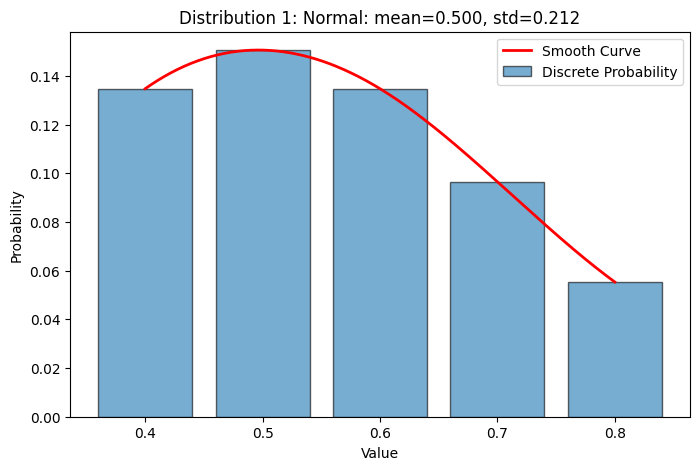

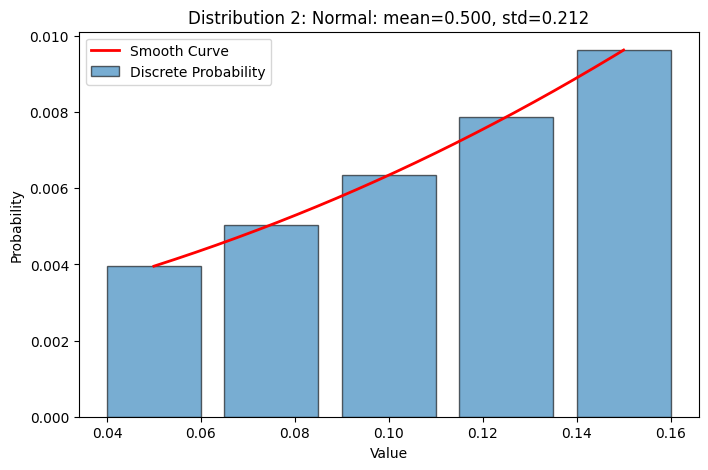

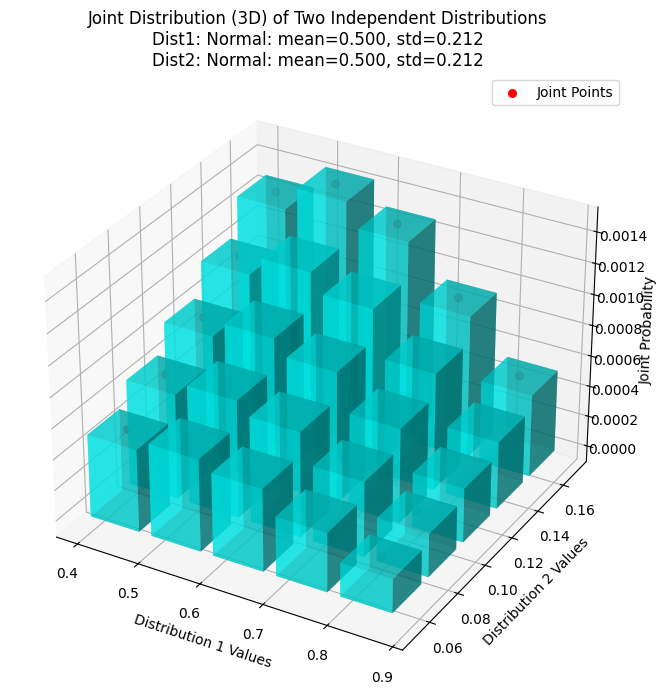

In [35]:
normal_params1 = {
    'type': 'normal',
    'X_min': 0.4,
    'X_max': 0.8,
    'n_points': 5,
    'std_low': 0.01,
    'std_high': 0.3,
    'dist_min': 0.0,  # Parameter range for the underlying distribution
    'dist_max': 1.0
}

normal_params2 = {
    'type': 'normal',
    'X_min': 0.05,
    'X_max': 0.15,
    'n_points': 5,
    'std_low': 0.01,
    'std_high': 0.3,
    'dist_min': 0.0,  # Parameter range for the underlying distribution
    'dist_max': 1.0
}

plot_joint_distribution_3d(normal_params1, normal_params2, seed1=123, seed2=123,
                           csv_filename1="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_win.csv", csv_filename2="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_jackpot.csv")
